In [2]:
from pandas import read_csv
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

In [4]:
df = read_csv("../../datasets/heart-disease.csv")

# This dataset contains non numeric values. see previous lessons.
index_to_delete = []

print(df.dtypes)
            

age                                                      int64
sex                                                      int64
chest pain type                                          int64
resting blood presure                                    int64
serum cholestoral                                        int64
fasting blood sugar > 120 mg/dl                          int64
resting electrocardiographic results                     int64
maximum heart rate achieved                              int64
exercise induced angina                                  int64
ST depression induced by exercise relative to rest     float64
the slope of the peak exercise ST segment                int64
number of major vessels (0-3) colored by flourosopy     object
thal                                                    object
diagnosis of heart disease                               int64
dtype: object


In [19]:
# df['number of major vessels (0-3) colored by flourosopy'].value_counts()
for h in df.columns:
    print(df[h].value_counts())
    print("---")

# for x in df.index:
#     if not df.loc[x, 'thal'].isdigit():
#         df.drop(x, inplace=True)
# df.dtypes

age
58    18
57    17
54    16
59    14
60    12
51    12
56    11
62    11
44    11
52    11
64    10
41    10
67     9
63     9
42     8
45     8
55     8
61     8
65     8
50     7
66     7
43     7
48     7
53     7
46     7
47     5
49     5
70     4
68     4
35     4
39     4
69     3
71     3
40     3
34     2
37     2
29     1
77     1
38     1
74     1
76     1
Name: count, dtype: int64
---
sex
1    201
0     96
Name: count, dtype: int64
---
chest pain type
4    142
3     83
2     49
1     23
Name: count, dtype: int64
---
resting blood presure
120    37
130    36
140    32
110    19
150    17
160    11
138    10
128    10
125    10
112     9
132     7
118     7
124     6
108     6
135     6
152     5
134     5
145     5
100     4
170     4
122     4
126     3
136     3
115     3
180     3
142     3
105     3
102     2
146     2
144     2
148     2
178     2
94      2
165     1
123     1
114     1
154     1
156     1
106     1
155     1
172     1
200     1
101     1
129     1
1

In [17]:
# ndf = df.drop(index=index_to_delete).reset_index()
x = np.asarray(ndf[['age', 'sex', 'chest pain type', 'resting blood presure',
       'serum cholestoral', 'fasting blood sugar > 120 mg/dl',
       'resting electrocardiographic results', 'maximum heart rate achieved',
       'exercise induced angina',
       'ST depression induced by exercise relative to rest',
       'the slope of the peak exercise ST segment',
       'number of major vessels (0-3) colored by flourosopy', 'thal']].values)

x = preprocessing.StandardScaler().fit(x).transform(x)
y = np.asarray(ndf['diagnosis of heart disease'].values)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=4)
print("training data: ", x_train.shape, y_train.shape)
print("testing data: ", x_test.shape, y_test.shape)

ValueError: could not convert string to float: '?'

In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
LogReg = LogisticRegression(C=0.01, solver='liblinear').fit(x_train, y_train)
# C is used to decrease overfit.
LogReg

LogisticRegression(C=0.01, solver='liblinear')

In [75]:
yhat = LogReg.predict(x_test)
print(yhat[0:6])
print(y_test[0:6])

[1 0 0 1 0 1]
[1 0 1 1 0 1]


In [70]:
yhat_prob = LogReg.predict_proba(x_test)
# There are 5 type of diagnose. 0,1,2,3,4. it shows probability of each of them.
yhat_prob[0:6]

array([[0.41584787, 0.58415213],
       [0.55953821, 0.44046179],
       [0.5556653 , 0.4443347 ],
       [0.17452528, 0.82547472],
       [0.74405715, 0.25594285],
       [0.44457919, 0.55542081]])

In [73]:
from sklearn.metrics import jaccard_score as js
from sklearn import metrics
print("acc score: %f"%(metrics.accuracy_score(y_test, yhat)))
print("f1 score: %f"%(metrics.f1_score(y_test, yhat, average='micro')))
print("Jac score for 0: %f"%(js(y_test, yhat, average='micro', labels=[0])))
print("Jac score for 1: %f"%(js(y_test, yhat, average='micro', labels=[1])))

acc score: 0.833333
f1 score: 0.833333
Jac score for 0: 0.705882
Jac score for 1: 0.722222


In [72]:
print(metrics.classification_report(y_test, yhat))

              precision    recall  f1-score   support

           0       0.80      0.86      0.83        42
           1       0.87      0.81      0.84        48

    accuracy                           0.83        90
   macro avg       0.83      0.83      0.83        90
weighted avg       0.84      0.83      0.83        90



In [83]:
cm = metrics.confusion_matrix(y_test, yhat)
cm

array([[36,  6],
       [ 9, 39]], dtype=int64)

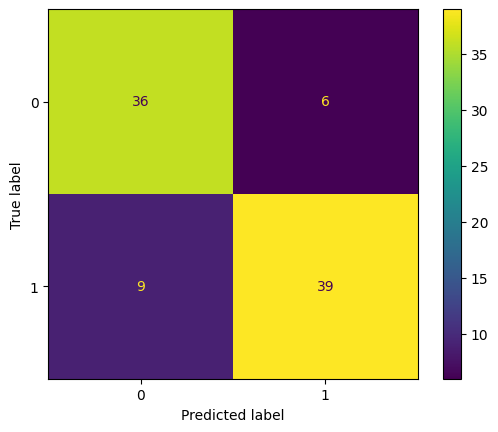

In [82]:
disp = metrics.ConfusionMatrixDisplay(cm)
disp.plot()
